# 4. Multi-Digital Twin Fusion

Two fusion methods under the multi-twin cooperative operation mechanism:

**Method 1: Single Metric Dynamic Preference (Time Window)**
- Selects the best model (lowest RMSE) in each sliding window of size 10
- Window slides one step at a time

**Method 2: Multi-Metrics Dynamic Fusion (DS Evidence Theory)**
- Computes BPAs from RMSE, MAE, R^2 for each model
- Fuses using Dempster-Shafer combination rule
- Threshold zeta = 0.03 for winner-take-all

Tests all combinations: 2-DT, 3-DT, and 4-DT


In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from evaluate import compute_metrics, metrics_to_table
from fusion import method1_single_metric_preference, method2_ds_fusion, run_all_fusion

# Load config and data
with open('results/config.json', 'r') as f:
    config = json.load(f)
feature_cols = config['feature_cols']
target_col = config['target_col']
WINDOW_SIZE = config['window_size']
scaler = joblib.load('results/scaler.save')

# Load predictions
model_names = ['LSTM', 'GRU', 'LSTMCNN', 'GRUCNN']
predictions_dict = {}
for name in model_names:
    df = pd.read_csv(f'results/predictions/{name}_predictions.csv')
    predictions_dict[name] = df['prediction'].values

actuals = pd.read_csv(f'results/predictions/LSTM_predictions.csv')['actual'].values

print(f"[OK] Loaded {len(model_names)} model predictions ({len(actuals)} test samples)")
print(f"Window size: {WINDOW_SIZE}")


[OK] Loaded 4 model predictions (853 test samples)
Window size: 10


## 4.1 Method 1: Single Metric Dynamic Preference

For each prediction point:
1. Look at the past 10 points (time window)
2. Compute RMSE for each model in that window
3. Select the model with **lowest RMSE** for the next prediction


In [2]:
from itertools import combinations

m1_results = {}
for r in [2, 3, 4]:
    for combo in combinations(model_names, r):
        combo_name = '&'.join(combo)
        combo_preds = {n: predictions_dict[n] for n in combo}
        
        m1_pred, m1_actual, selections = method1_single_metric_preference(
            combo_preds, actuals, WINDOW_SIZE
        )
        m1_metrics = compute_metrics(m1_actual, m1_pred, print_results=False)
        m1_results[combo_name] = m1_metrics
        print(f"  {combo_name}: MAE={m1_metrics['MAE']}, RMSE={m1_metrics['RMSE']}, R2={m1_metrics['R2']}")

print(f"\n[OK] Method 1 computed for {len(m1_results)} combinations")


  LSTM&GRU: MAE=0.0398, RMSE=0.0579, R2=0.9334
  LSTM&LSTMCNN: MAE=0.0416, RMSE=0.0599, R2=0.9288
  LSTM&GRUCNN: MAE=0.0414, RMSE=0.0608, R2=0.9266
  GRU&LSTMCNN: MAE=0.0403, RMSE=0.059, R2=0.9308


  GRU&GRUCNN: MAE=0.0394, RMSE=0.0587, R2=0.9315
  LSTMCNN&GRUCNN: MAE=0.0432, RMSE=0.0619, R2=0.9238


  LSTM&GRU&LSTMCNN: MAE=0.0405, RMSE=0.0592, R2=0.9304
  LSTM&GRU&GRUCNN: MAE=0.04, RMSE=0.0593, R2=0.93


  LSTM&LSTMCNN&GRUCNN: MAE=0.0413, RMSE=0.0611, R2=0.9259
  GRU&LSTMCNN&GRUCNN: MAE=0.0401, RMSE=0.0597, R2=0.9291
  LSTM&GRU&LSTMCNN&GRUCNN: MAE=0.0404, RMSE=0.06, R2=0.9285

[OK] Method 1 computed for 11 combinations


In [3]:
# Method 1 Results Table
m1_df = pd.DataFrame(m1_results).T
m1_df.index.name = 'Combination'
print("="*70)
print("  METHOD 1: Single Metric Dynamic Preference (RMSE-based)")
print("="*70)
print(m1_df.to_string())


  METHOD 1: Single Metric Dynamic Preference (RMSE-based)
                            MAE    RMSE    NMAE     MAPE      R2
Combination                                                     
LSTM&GRU                 0.0398  0.0579  4.1456   9.9194  0.9334
LSTM&LSTMCNN             0.0416  0.0599  4.3312  10.8380  0.9288
LSTM&GRUCNN              0.0414  0.0608  4.3142   9.2382  0.9266
GRU&LSTMCNN              0.0403  0.0590  4.1957  10.2927  0.9308
GRU&GRUCNN               0.0394  0.0587  4.1102   8.6177  0.9315
LSTMCNN&GRUCNN           0.0432  0.0619  4.4978   9.2960  0.9238
LSTM&GRU&LSTMCNN         0.0405  0.0592  4.2217  10.3860  0.9304
LSTM&GRU&GRUCNN          0.0400  0.0593  4.1722   9.0097  0.9300
LSTM&LSTMCNN&GRUCNN      0.0413  0.0611  4.3031   9.5551  0.9259
GRU&LSTMCNN&GRUCNN       0.0401  0.0597  4.1752   9.0747  0.9291
LSTM&GRU&LSTMCNN&GRUCNN  0.0404  0.0600  4.2054   9.2969  0.9285


## 4.2 Method 2: Multi-Metrics DS Evidence Fusion

For each prediction point:
1. Compute BPAs from **RMSE, MAE, R^2** for each model
2. Fuse using **Dempster-Shafer combination rule**
3. If variance of weights > zeta (0.03), use **winner-take-all**
4. Otherwise, use **weighted combination** of predictions


In [4]:
m2_results = {}
for r in [2, 3, 4]:
    for combo in combinations(model_names, r):
        combo_name = '&'.join(combo)
        combo_preds = {n: predictions_dict[n] for n in combo}
        
        m2_pred, m2_actual = method2_ds_fusion(
            combo_preds, actuals, WINDOW_SIZE, zeta=0.03
        )
        m2_metrics = compute_metrics(m2_actual, m2_pred, print_results=False)
        m2_results[combo_name] = m2_metrics
        print(f"  {combo_name}: MAE={m2_metrics['MAE']}, RMSE={m2_metrics['RMSE']}, R2={m2_metrics['R2']}")

print(f"\n[OK] Method 2 computed for {len(m2_results)} combinations")


  LSTM&GRU: MAE=0.0398, RMSE=0.0579, R2=0.9334


  LSTM&LSTMCNN: MAE=0.0416, RMSE=0.0599, R2=0.9288


  LSTM&GRUCNN: MAE=0.0414, RMSE=0.0608, R2=0.9266


  GRU&LSTMCNN: MAE=0.0403, RMSE=0.059, R2=0.9308


  GRU&GRUCNN: MAE=0.0394, RMSE=0.0587, R2=0.9315


...

  LSTM&GRU&LSTMCNN: MAE=0.0404, RMSE=0.0589, R2=0.9311


  LSTM&GRU&GRUCNN: MAE=0.0398, RMSE=0.0591, R2=0.9307


  LSTM&LSTMCNN&GRUCNN: MAE=0.0415, RMSE=0.0609, R2=0.9263


  GRU&LSTMCNN&GRUCNN: MAE=0.0402, RMSE=0.06, R2=0.9284


  LSTM&GRU&LSTMCNN&GRUCNN: MAE=0.0402, RMSE=0.0598, R2=0.929

[OK] Method 2 computed for 11 combinations


In [5]:
# Method 2 Results Table
m2_df = pd.DataFrame(m2_results).T
m2_df.index.name = 'Combination'
print("="*70)
print("  METHOD 2: Multi-Metrics Dynamic Fusion (DS Evidence Theory)")
print("="*70)
print(m2_df.to_string())


  METHOD 2: Multi-Metrics Dynamic Fusion (DS Evidence Theory)
                            MAE    RMSE    NMAE     MAPE      R2
Combination                                                     
LSTM&GRU                 0.0398  0.0579  4.1442   9.9194  0.9334
LSTM&LSTMCNN             0.0416  0.0599  4.3324  10.8380  0.9288
LSTM&GRUCNN              0.0414  0.0608  4.3137   9.2382  0.9266
GRU&LSTMCNN              0.0403  0.0590  4.1955  10.2927  0.9308
GRU&GRUCNN               0.0394  0.0587  4.1102   8.6177  0.9315
LSTMCNN&GRUCNN           0.0432  0.0620  4.4991   9.2960  0.9237
LSTM&GRU&LSTMCNN         0.0404  0.0589  4.2129  10.2701  0.9311
LSTM&GRU&GRUCNN          0.0398  0.0591  4.1442   9.0049  0.9307
LSTM&LSTMCNN&GRUCNN      0.0415  0.0609  4.3253   9.6068  0.9263
GRU&LSTMCNN&GRUCNN       0.0402  0.0600  4.1916   9.0913  0.9284
LSTM&GRU&LSTMCNN&GRUCNN  0.0402  0.0598  4.1838   9.2445  0.9290


## 4.3 Comparison: Single DT vs MDT

In [6]:
# Load single DT metrics
single_df = pd.read_csv('results/single_dt_metrics.csv', index_col=0)
single_metrics = single_df.to_dict('index')

best_single = min(single_metrics, key=lambda k: single_metrics[k]['MAE'])
best_m1 = min(m1_results, key=lambda k: m1_results[k]['MAE'])
best_m2 = min(m2_results, key=lambda k: m2_results[k]['MAE'])

print("="*70)
print("  BEST RESULTS SUMMARY")
print("="*70)
print(f"  Best Single DT: {best_single}")
print(f"    MAE={single_metrics[best_single]['MAE']}, RMSE={single_metrics[best_single]['RMSE']}, R2={single_metrics[best_single]['R2']}")
print(f"")
print(f"  Best Method 1:  {best_m1}")
print(f"    MAE={m1_results[best_m1]['MAE']}, RMSE={m1_results[best_m1]['RMSE']}, R2={m1_results[best_m1]['R2']}")
print(f"")
print(f"  Best Method 2:  {best_m2}")
print(f"    MAE={m2_results[best_m2]['MAE']}, RMSE={m2_results[best_m2]['RMSE']}, R2={m2_results[best_m2]['R2']}")


  BEST RESULTS SUMMARY
  Best Single DT: GRU
    MAE=0.0393, RMSE=0.0576, R2=0.934

  Best Method 1:  GRU&GRUCNN
    MAE=0.0394, RMSE=0.0587, R2=0.9315

  Best Method 2:  GRU&GRUCNN
    MAE=0.0394, RMSE=0.0587, R2=0.9315


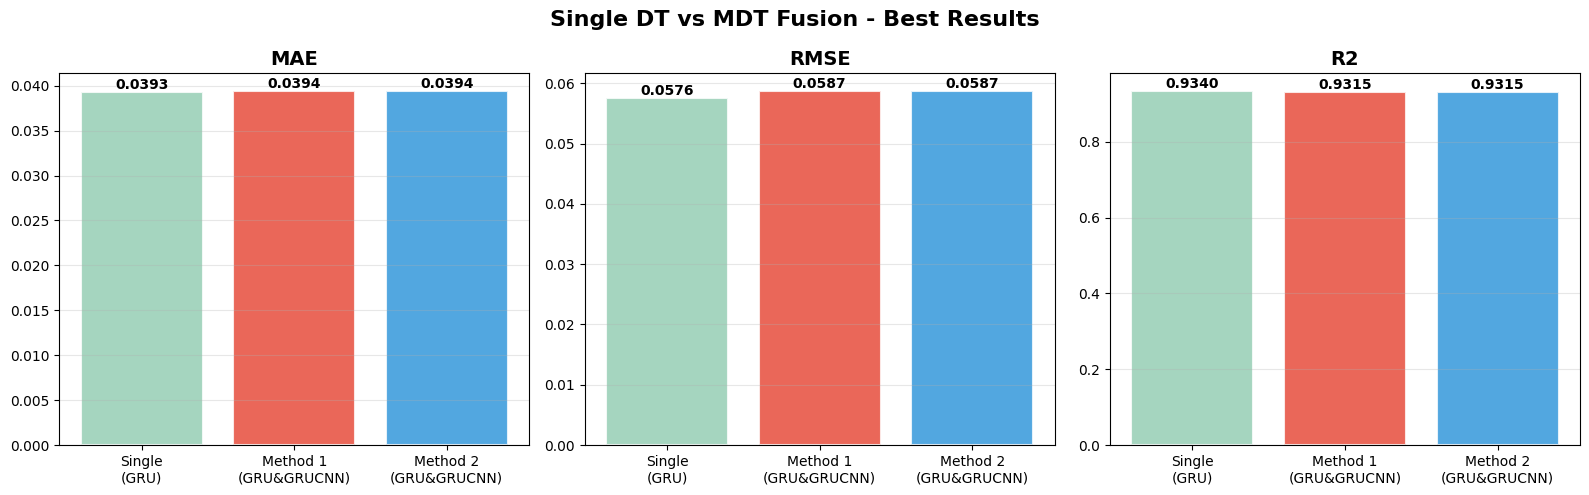

In [7]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Single DT vs MDT Fusion - Best Results', fontsize=16, fontweight='bold')

labels = [f'Single\n({best_single})', f'Method 1\n({best_m1})', f'Method 2\n({best_m2})']
bar_colors = ['#96CEB4', '#E74C3C', '#3498DB']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = [
        single_metrics[best_single][metric],
        m1_results[best_m1][metric],
        m2_results[best_m2][metric]
    ]
    bars = ax.bar(labels, vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/fusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.4 1-Day Forecast: Best Fusion vs Single Models

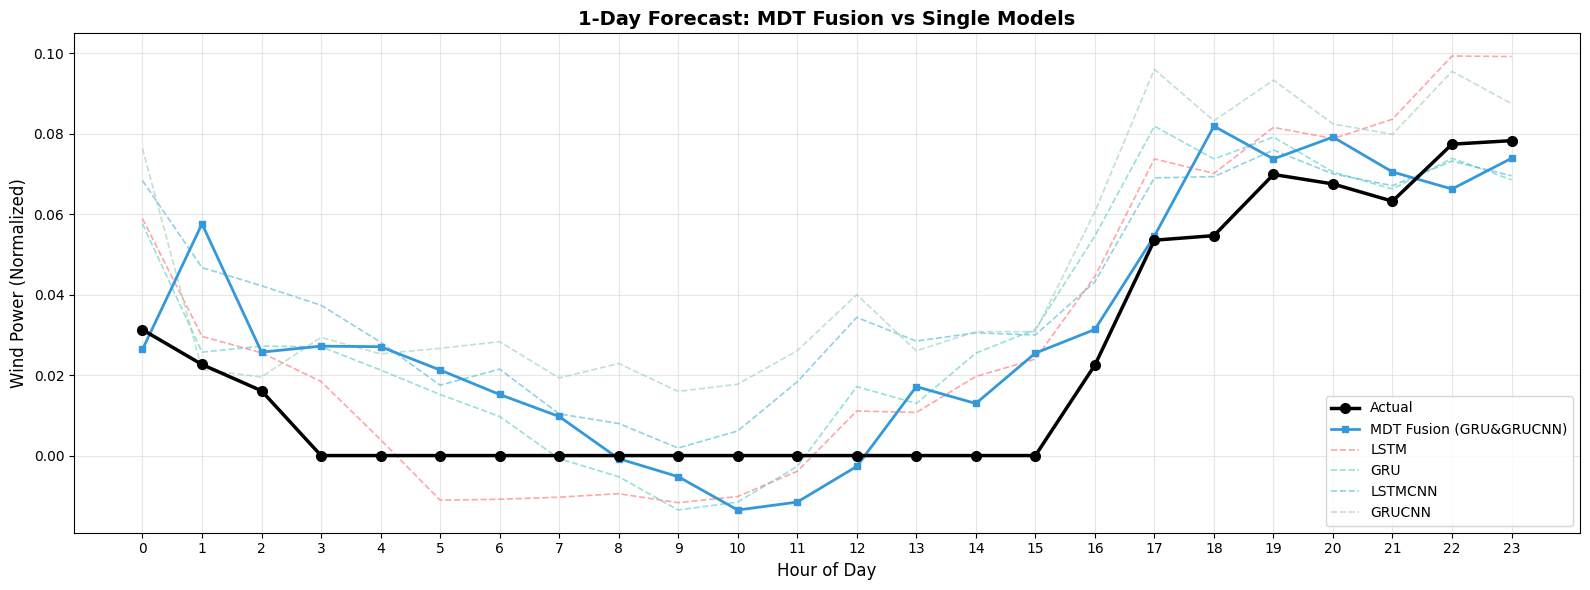

In [8]:
# Run best fusion on test data for plotting
best_m2_models = best_m2.split('&')
combo_preds = {n: predictions_dict[n] for n in best_m2_models}
m2_pred_best, m2_actual_best = method2_ds_fusion(combo_preds, actuals, WINDOW_SIZE, zeta=0.03)

# Plot 1 day
start = 0
end = min(24, len(m2_pred_best))
hours = np.arange(end)

actual_kw = m2_actual_best[start:end]
fusion_kw = m2_pred_best[start:end]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(hours, actual_kw, 'ko-', linewidth=2.5, markersize=7, label='Actual', zorder=5)
ax.plot(hours, fusion_kw, 's-', color='#3498DB', linewidth=2, markersize=5, label=f'MDT Fusion ({best_m2})', zorder=4)

# Also plot individual models
colors_map = {'LSTM': '#FF6B6B', 'GRU': '#4ECDC4', 'LSTMCNN': '#45B7D1', 'GRUCNN': '#96CEB4'}
for name in model_names:
    pred_kw = predictions_dict[name][WINDOW_SIZE+1:WINDOW_SIZE+1+end]
    ax.plot(hours, pred_kw, '--', color=colors_map[name], linewidth=1.2, alpha=0.6, label=name)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Wind Power (Normalized)', fontsize=12)
ax.set_title('1-Day Forecast: MDT Fusion vs Single Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)
plt.tight_layout()
plt.savefig('results/plots/fusion_1day.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.5 Save All Results

In [9]:
m1_df.to_csv('results/method1_fusion_metrics.csv')
m2_df.to_csv('results/method2_fusion_metrics.csv')

print("[OK] Saved:")
print("  results/method1_fusion_metrics.csv")
print("  results/method2_fusion_metrics.csv")
print()
print("=== All Results Files ===")
for root, dirs, files in os.walk('results'):
    for f in sorted(files):
        print(f"  {os.path.join(root, f)}")


[OK] Saved:
  results/method1_fusion_metrics.csv
  results/method2_fusion_metrics.csv

=== All Results Files ===
  results\config.json
  results\method1_fusion_metrics.csv
  results\method2_fusion_metrics.csv
  results\scaler.save
  results\single_dt_metrics.csv
  results\test_data.csv
  results\train_data.csv
  results\val_data.csv
  results\models\GRUCNN_best.pth
  results\models\GRU_best.pth
  results\models\LSTMCNN_best.pth
  results\models\LSTM_best.pth
  results\plots\correlation.png
  results\plots\day_1_forecast.png
  results\plots\day_2_forecast.png
  results\plots\day_3_forecast.png
  results\plots\distributions.png
  results\plots\error_dist.png
  results\plots\final_comparison.png
  results\plots\fusion_1day.png
  results\plots\fusion_comparison.png
  results\plots\fusion_heatmap.png
  results\plots\metrics_comparison.png
  results\plots\power_curve.png
  results\plots\scatter.png
  results\plots\scatter_inline.png
  results\plots\single_metrics.png
  results\plots\test_ove